In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# EnhancedNormModel 64x64 Image and 5 Conv Blocks
# Using OverSampled high-alert and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.EnhancedNormModel import EnhancedNormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 2
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 16` 
* `initial_image_size = 64`
* `poolings = [1,1,1,1]`
* `normalizations = [1, 1, 1, 1]`,
* `dropouts = [0, 1, 0, 1]`

In [6]:
model = EnhancedNormModel(
    conv_layers=5, 
    normalizations = [1, 1, 1, 1, 1],
    poolings = [1,1,1,1, 1],
    dropouts = [0, 0, 1, 0, 1],
    initial_output_channel=16, 
    initial_image_size=64,
    dropout_p = 0.2
    ).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=30,
    lr=0.002,
    print_on=1,
    save_dir="../models/en_norm_img64_c5_lr_0.002_os/",
    save_checkpoints=1,
    checkpoint_name="en_norm_64x64_train_0_",
    early_stop_patience = 6,
    min_delta = 0.01
)

Epoch 1/30 | Train Loss: 0.9806 | Valid Loss: 0.9324
Epoch 2/30 | Train Loss: 0.8538 | Valid Loss: 0.9291
Epoch 3/30 | Train Loss: 0.7566 | Valid Loss: 0.8595
Epoch 4/30 | Train Loss: 0.6712 | Valid Loss: 0.8611
Epoch 5/30 | Train Loss: 0.6089 | Valid Loss: 0.9093
Epoch 6/30 | Train Loss: 0.5592 | Valid Loss: 0.6689
Epoch 7/30 | Train Loss: 0.5189 | Valid Loss: 0.7092
Epoch 8/30 | Train Loss: 0.4849 | Valid Loss: 0.6594
Epoch 9/30 | Train Loss: 0.4463 | Valid Loss: 0.7772
Epoch 10/30 | Train Loss: 0.4282 | Valid Loss: 0.6328
Epoch 11/30 | Train Loss: 0.3981 | Valid Loss: 0.6590
Epoch 12/30 | Train Loss: 0.3710 | Valid Loss: 0.7357
Epoch 13/30 | Train Loss: 0.3511 | Valid Loss: 0.6588
Epoch 14/30 | Train Loss: 0.3357 | Valid Loss: 0.6607
Epoch 15/30 | Train Loss: 0.3294 | Valid Loss: 0.6293
Early stopping at epoch 16 | No improvement for 6 epochs


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [11]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [12]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,0.980597,0.513069,0.511549,0.513017,0.511755,0.932391,0.529013,0.527155,0.558432,0.416260
1,2,0.853771,0.604098,0.601777,0.604400,0.602285,0.929075,0.572639,0.569374,0.585979,0.500706
2,3,0.756649,0.662978,0.661632,0.663642,0.661964,0.859493,0.623465,0.571519,0.652112,0.551548
3,4,0.671198,0.711794,0.709897,0.711723,0.710098,0.861134,0.626006,0.569091,0.653577,0.556082
4,5,0.608892,0.744308,0.742497,0.744781,0.742863,0.909344,0.606946,0.592265,0.607819,0.527987
5,6,0.559184,0.764344,0.761888,0.763389,0.761904,0.668851,0.712834,0.604302,0.626669,0.608840
6,7,0.518902,0.781056,0.778093,0.779356,0.778102,0.709194,0.690385,0.597851,0.575272,0.570909
7,8,0.484862,0.797678,0.796070,0.797937,0.796404,0.659376,0.728928,0.625077,0.656432,0.632256
8,9,0.446275,0.815027,0.814161,0.815571,0.814323,0.777243,0.697162,0.605832,0.693324,0.622291
9,10,0.428168,0.822313,0.820376,0.821888,0.820822,0.632815,0.738247,0.638948,0.655552,0.644955


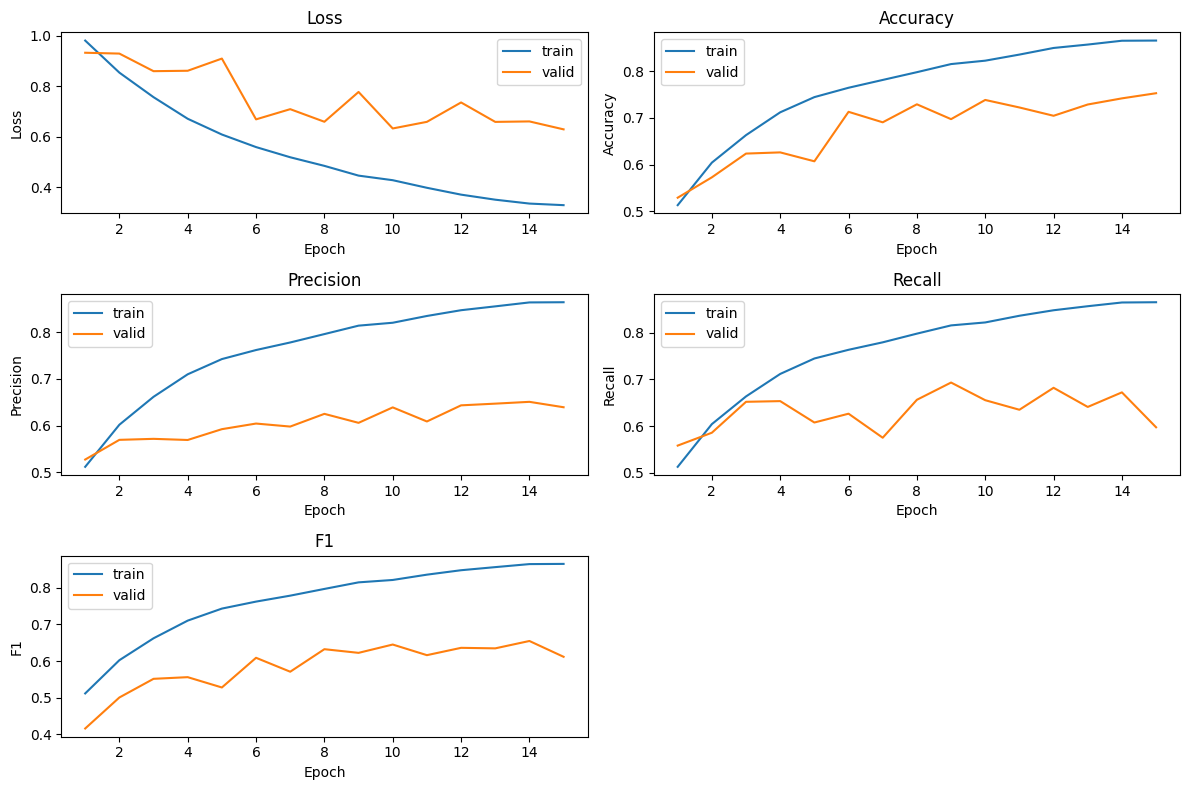

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()